In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [31]:

from src.data_loader import load_data


data = load_data('../data/raw/Mall_Customers.csv')

data.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [33]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [34]:
data.shape

(200, 5)

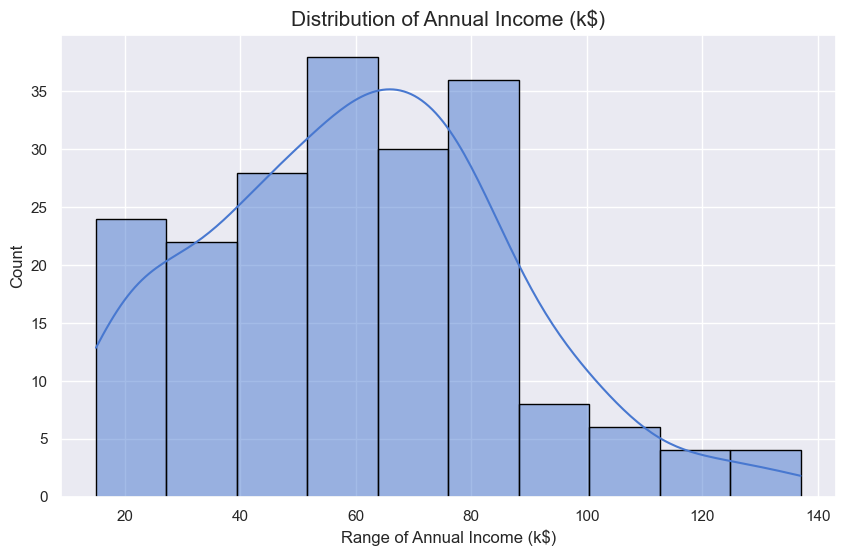

In [35]:

# Annual Income distribution

sns.set_theme(style='darkgrid', palette='muted', context='notebook')

fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(    data['Annual Income (k$)'], kde=True,edgecolor='black')
plt.title('Distribution of Annual Income (k$)', fontsize = 15)
plt.xlabel('Range of Annual Income (k$)')
plt.ylabel('Count')

plt.savefig("../reports/figures/Annual_income_distribution.png")


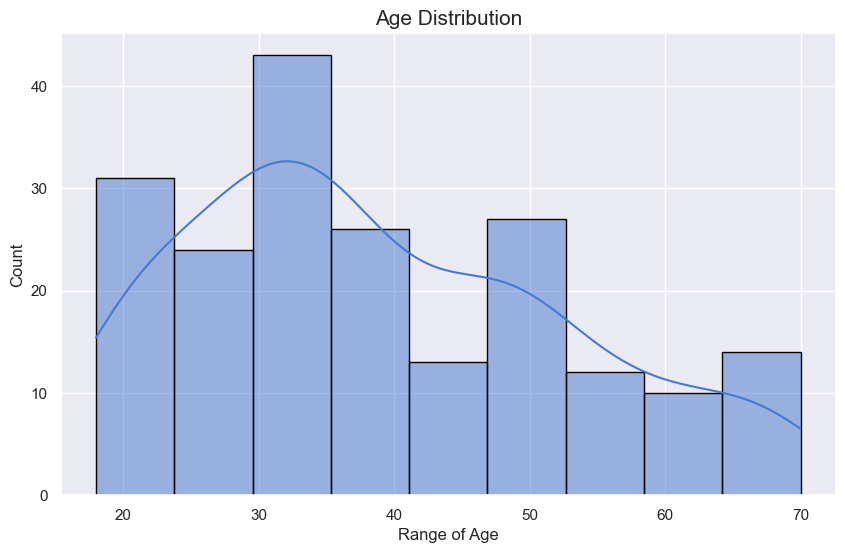

In [36]:
# Age distribution

fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(data['Age'], edgecolor='black', kde=True)
plt.title('Age Distribution', fontsize = 15)
plt.xlabel('Range of Age')
plt.ylabel('Count')

plt.savefig("../reports/figures/Age_distribution.png")

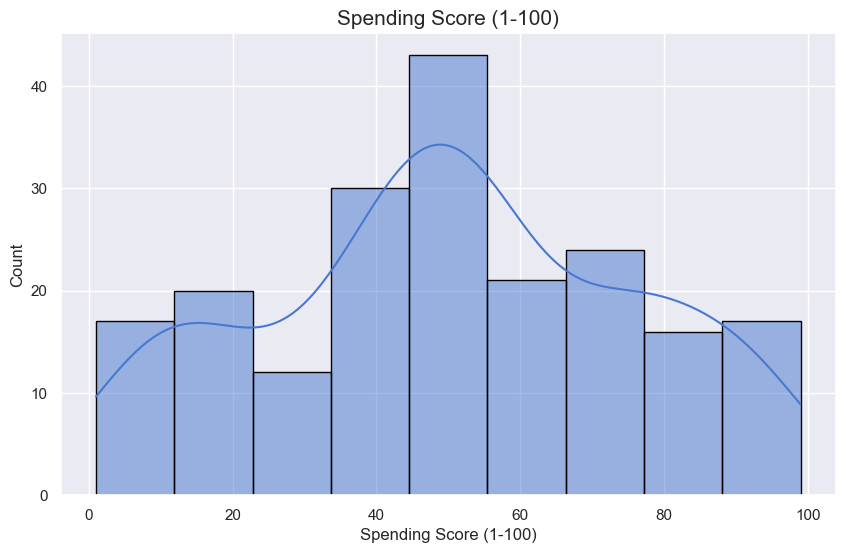

In [37]:
# Spending score distribution

fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data['Spending Score (1-100)'],
    edgecolor='black',kde=True)
plt.title('Spending Score (1-100)',fontsize = 15)
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Count')

plt.savefig("../reports/figures/Spending_score_distribution.png")

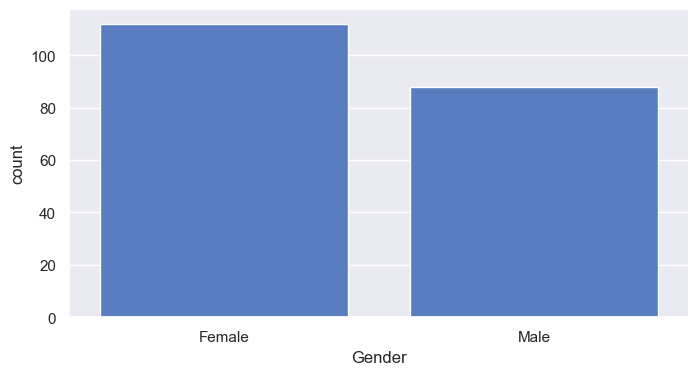

In [38]:
# Gender
plt.figure(1, figsize=(8,4))
sns.barplot(data['Gender'].value_counts())

plt.savefig("../reports/figures/Gender_distribution.png")

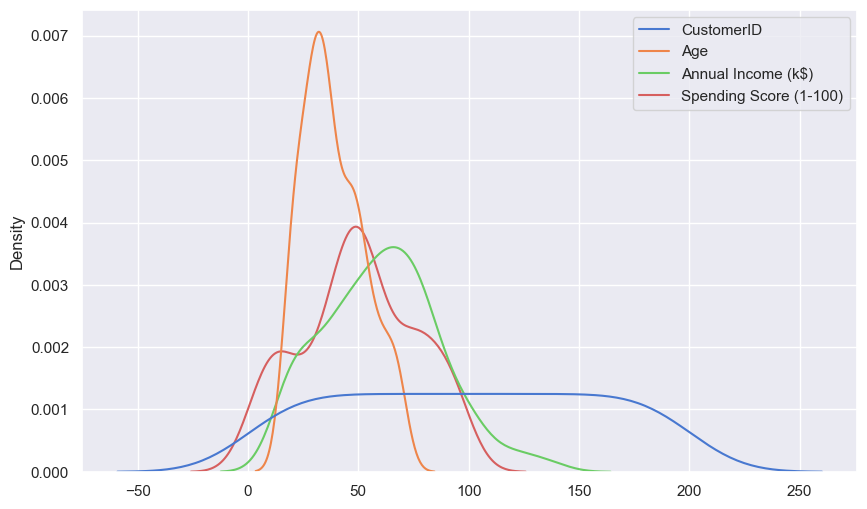

In [39]:

fig, ax = plt.subplots(figsize=(10,6))
sns.kdeplot(data)

plt.savefig("../reports/figures/Kde_plot.png")



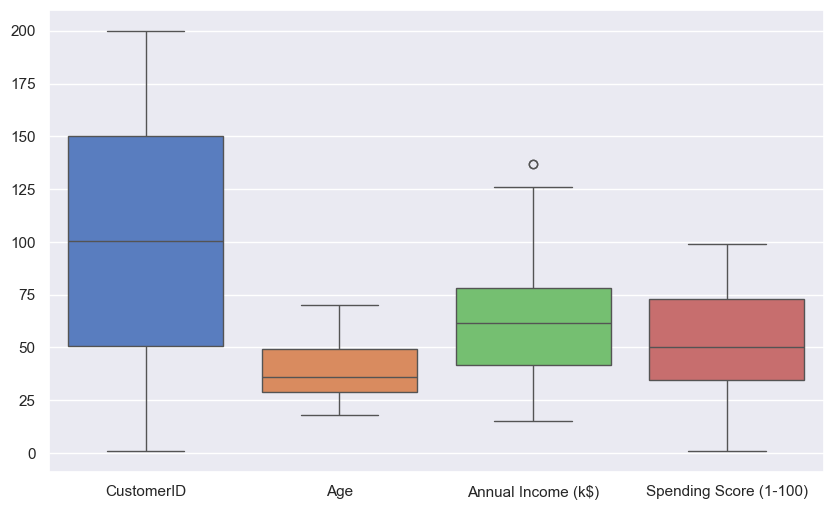

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data)

plt.savefig("../reports/figures/Box_plot.png")

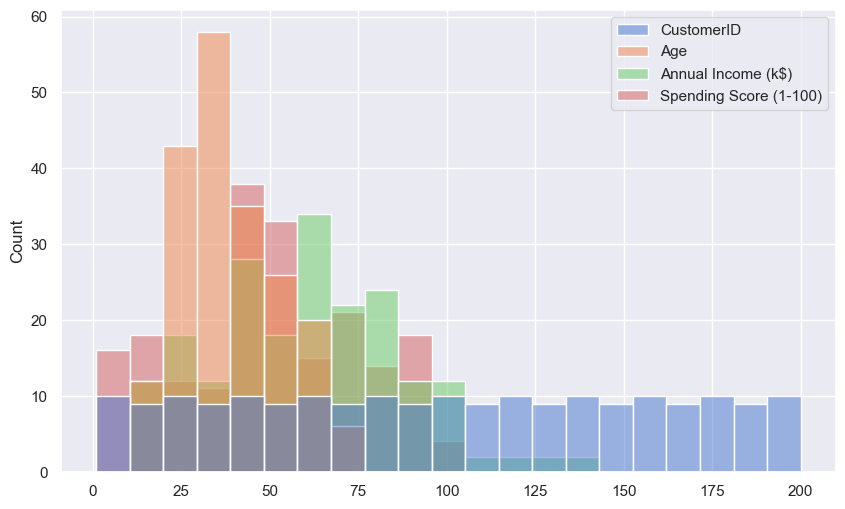

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data)

plt.savefig("../reports/figures/Hist_plot.png")

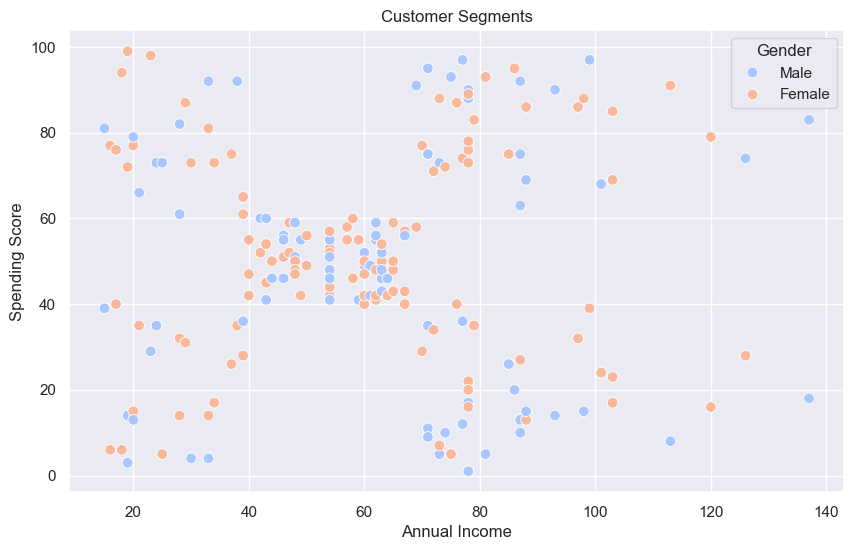

In [42]:
# Clustering based on 2 features

X = data[['Annual Income (k$)','Spending Score (1-100)','Gender']]

# sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data = X, s= 60, hue='Gender', palette=['orange','green'])

fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data = X, s= 60, hue='Gender', palette='coolwarm')

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")


plt.savefig("../reports/figures/Customer-Segments.png")

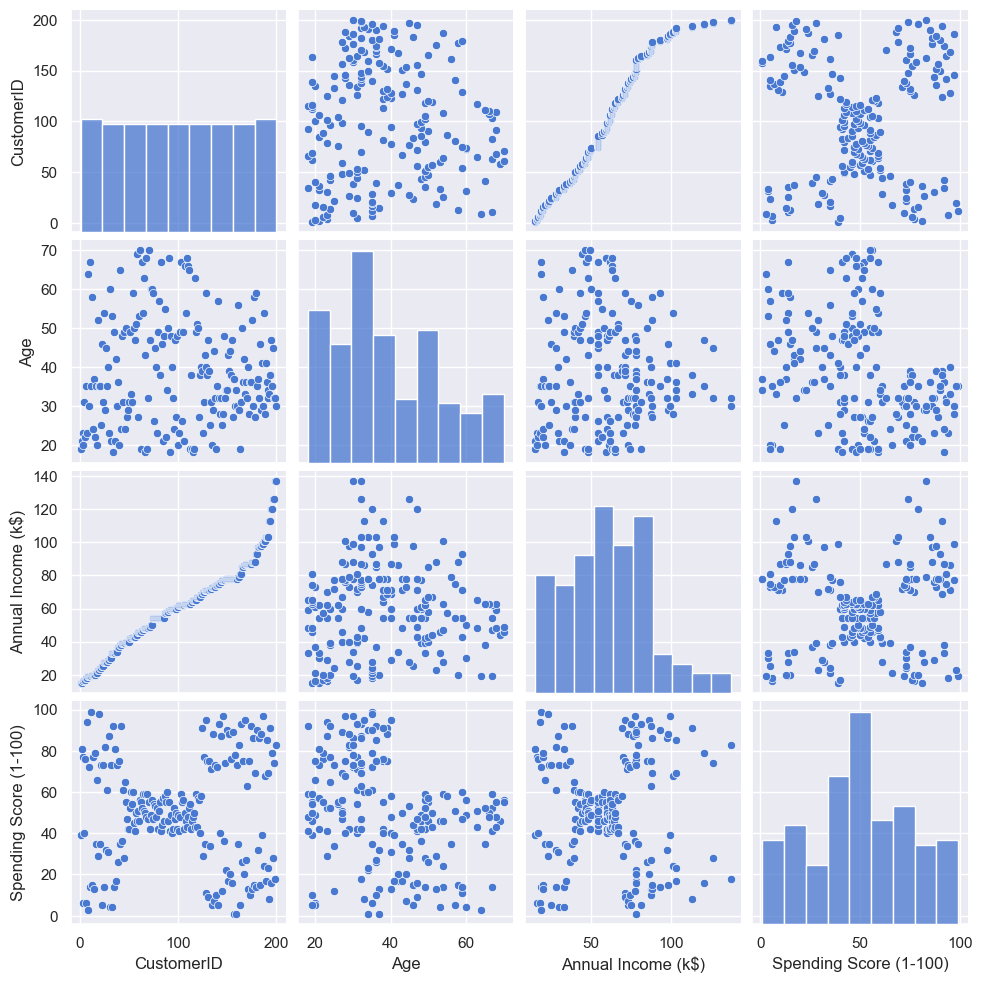

In [43]:
sns.pairplot(data)

plt.savefig("../reports/figures/Pair-Plot.png")

In [44]:
corr_mat = data.corr(numeric_only=True).style.background_gradient(cmap='coolwarm')

corr_mat

plt.savefig("../reports/figures/Correlation-Matrix.png")

<Figure size 640x480 with 0 Axes>

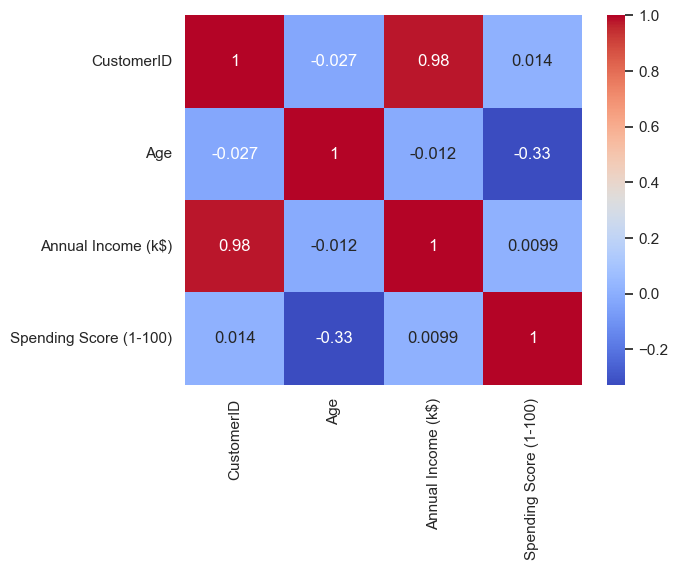

In [45]:
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm')

plt.savefig("../reports/figures/Correlation-Matrix.png")

In [46]:
# Elbow

X = data[['Annual Income (k$)','Spending Score (1-100)']]

wss = []

for i in range(1,11):
  km = KMeans(i)
  km.fit(X)
  wss.append(km.inertia_)

wss



[269981.28,
 186687.04312531714,
 106348.37306211119,
 82472.19413919412,
 44448.45544793371,
 37558.92202302528,
 30273.39431207004,
 25043.890043290045,
 22918.040562478152,
 19787.670554966855]

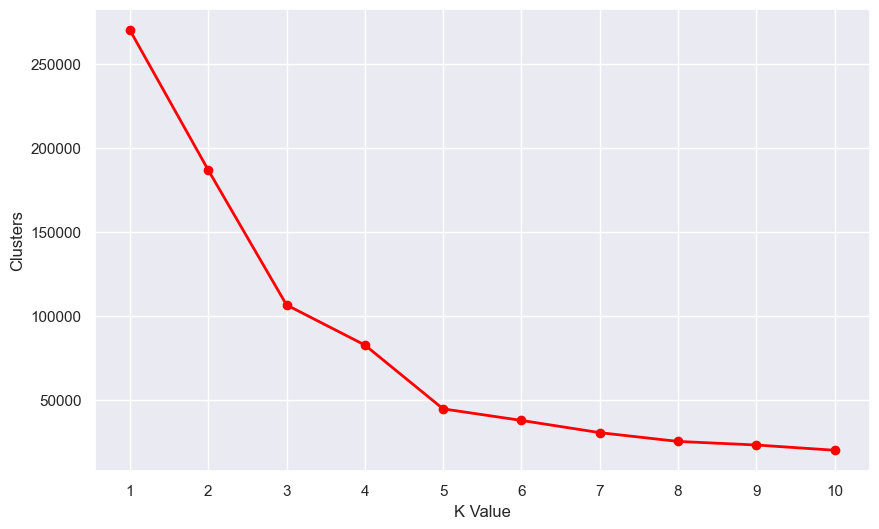

In [47]:
# Elbow Graph

plt.figure(2,figsize=(10,6))

plt.plot(range(1,11), wss, linewidth=2, color='red', marker='o')
plt.xlabel("K Value")
plt.xticks(np.arange(1,11,1))
plt.ylabel("Clusters")

plt.savefig("../reports/figures/Elbow-Curve.png")

In [48]:
km_model = KMeans(n_clusters=5)

km_model.fit(X)

y = km_model.predict(X)

data['label'] = y

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),label
0,1,Male,19,15,39,3
1,2,Male,21,15,81,0
2,3,Female,20,16,6,3
3,4,Female,23,16,77,0
4,5,Female,31,17,40,3


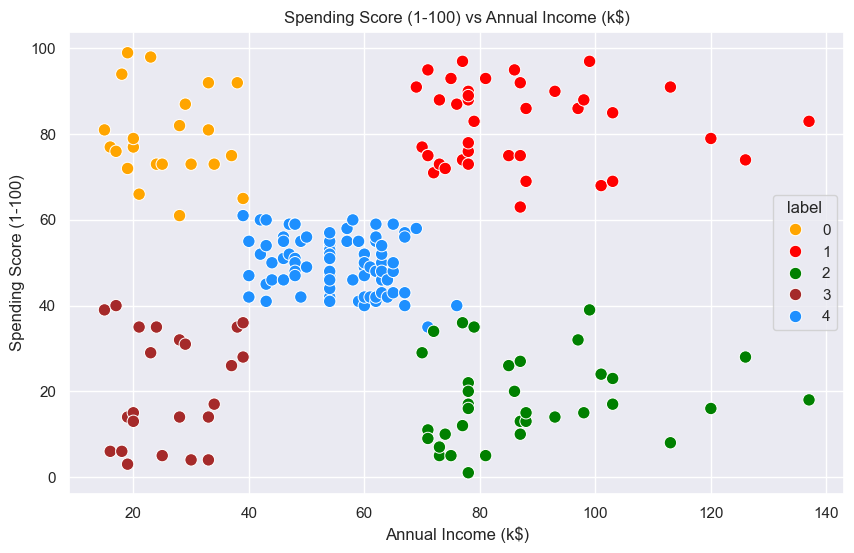

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data = data, s= 80, hue='label',legend = "full", palette=['orange','red','green','brown','dodgerblue'])

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score (1-100) vs Annual Income (k$)')

plt.savefig("../reports/figures/Spending Score-vs-Annual-Income.png")

In [50]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
 5   label                   200 non-null    int32
dtypes: int32(1), int64(4), str(1)
memory usage: 9.7 KB


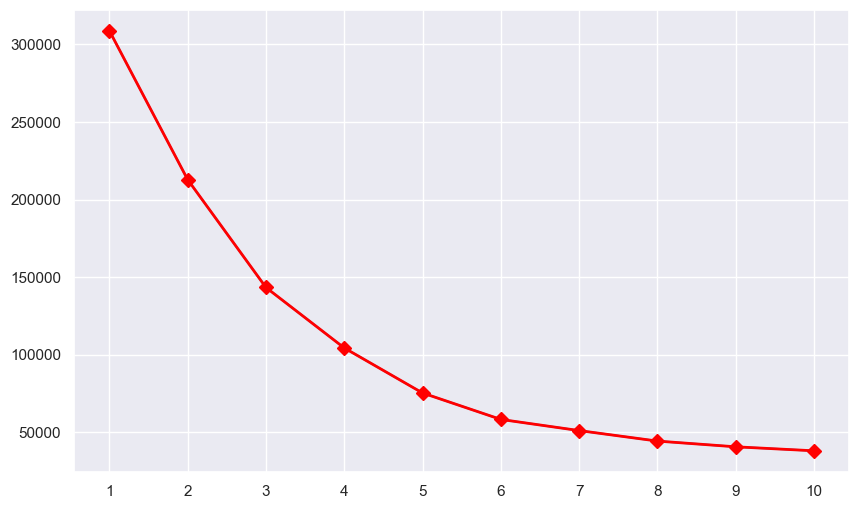

In [51]:
# k-Means Clustering on the basis of 3D data

X2 = data[['Age','Annual Income (k$)','Spending Score (1-100)']]

wss = []

for k in range(1,11):
  km_model = KMeans(k, init='k-means++',n_init=10)
  km_model.fit(X2)
  wss.append(km_model.inertia_)

plt.figure(2,figsize=(10,6))
plt.plot(range(1,11),wss)
plt.plot(range(1,11),wss, linewidth=2, color ='red', marker = 'D', markersize=7)
plt.xticks(range(1,11,1))


plt.savefig(
    "../reports/figures/k-Means-Clustering-on-the-basis-of-3D-data.png")

In [52]:

model = KMeans(n_clusters=5)

y = model.fit_predict(X2)

data['label1'] = y




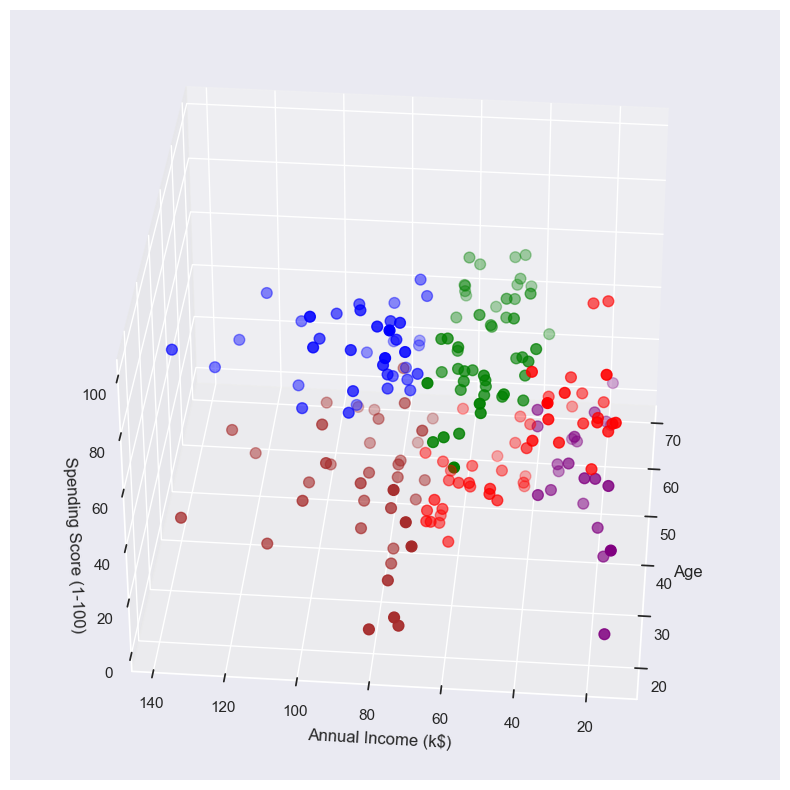

In [53]:
fig = plt.figure(figsize=(20,10))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(data.Age[data['label1'] == 0], data['Annual Income (k$)'][data['label1'] == 0], data['Spending Score (1-100)'][data['label1'] == 0], color='red' ,s = 60)
ax.scatter(data.Age[data['label1'] == 1], data['Annual Income (k$)'][data['label1'] == 1], data['Spending Score (1-100)'][data['label1'] == 1], color='purple',s = 60 )
ax.scatter(data.Age[data['label1'] == 2], data['Annual Income (k$)'][data['label1'] == 2], data['Spending Score (1-100)'][data['label1'] == 2], color='blue',s = 60 )
ax.scatter(data.Age[data['label1'] == 3], data['Annual Income (k$)'][data['label1'] == 3], data['Spending Score (1-100)'][data['label1'] == 3], color='green',s = 60 )
ax.scatter(data.Age[data['label1'] == 4], data['Annual Income (k$)'][data['label1'] == 4], data['Spending Score (1-100)'][data['label1'] == 4], color='brown' ,s = 60)

ax.view_init(35,185)

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
ax.set_zlabel('Spending Score (1-100)')

plt.savefig("../reports/figures/Customer-Segments-3D.png")

In [54]:

for i in range(0,5):
  cus = data[data['label1'] == i ]
  print("No of customers in the customers in {} group is : {}".format(i+1,len(cus)))
  print("They are Customer id is :{} ".format(cus['CustomerID'].to_numpy()))
  print("\n")

No of customers in the customers in 1 group is : 50
They are Customer id is :[  2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34  36
  38  40  42  44  46  48  49  50  52  53  59  62  66  69  70  76  79  85
  88  89  92  96  98 100 101 104 106 112 114 115 116 121] 


No of customers in the customers in 2 group is : 22
They are Customer id is :[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 43 45] 


No of customers in the customers in 3 group is : 39
They are Customer id is :[124 126 128 130 132 134 136 138 140 142 144 146 148 150 152 154 156 158
 160 162 164 166 168 170 172 174 176 178 180 182 184 186 188 190 192 194
 196 198 200] 


No of customers in the customers in 4 group is : 51
They are Customer id is :[ 41  47  51  54  55  56  57  58  60  61  63  64  65  67  68  71  72  73
  74  75  77  78  80  81  82  83  84  86  87  90  91  93  94  95  97  99
 102 103 105 107 108 109 110 111 113 117 118 119 120 122 123] 


No of customers in the customers in 5 gr